In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df = pd.read_csv('labeled_data_all_new.csv')

In [ ]:
df.head()

,Unnamed: 0.1,Unnamed: 0,mean_accelX,mean_accelY,mean_accelZ,median_accelX,median_accelY,median_accelZ,std_accelX,std_accelY,...,gyroY2,gyroY3,gyroY4,gyroZ0,gyroZ1,gyroZ2,gyroZ3,gyroZ4,activity_label,user_id
0,0,0,0.119612,-0.195769,0.241894,0.172317,-0.122617,0.197963,0.251581,0.115801,...,0.178802,0.003616,-0.466019,0.042114,-0.025818,-0.022156,-0.014343,-0.349075,Work,1
1,1,1,0.002185,0.002696,0.006802,-0.000624,0.004025,0.004922,0.008175,0.004232,...,0.011444,0.006073,0.003510,0.004288,0.003555,0.006851,0.002213,0.000504,Read,1
2,2,2,-0.015339,-0.073621,-0.118199,-0.015339,-0.073621,-0.118199,0.000000,0.000000,...,-0.035843,-0.035843,-0.035843,0.002762,0.002762,0.002762,0.002762,0.002762,Read,1
3,3,3,0.003313,0.001304,-0.000684,0.003313,0.001304,-0.000684,0.002503,0.002128,...,-0.000061,0.000061,-0.000412,0.000118,0.000244,0.000000,-0.000015,0.000244,Drive,1
4,4,4,0.044087,-0.010455,-0.011571,-0.003837,0.002575,0.000221,0.097911,0.034789,...,-0.000031,-0.000153,0.000107,-0.000015,0.367355,-0.000259,-0.000259,-0.000885,Walk,1


In [ ]:
df.fillna(0, inplace=True)

In [ ]:
# Take all the columns starting from mean_accelX and ending at gyroZ4

In [ ]:

X = df.iloc[:, 2:-2].values
y = df.iloc[:, -2].values

In [ ]:
np.set_printoptions(suppress=True)

In [ ]:
X

array([[ 0.11961184, -0.19576931,  0.24189434, ..., -0.02215576,
        -0.01434326, -0.34907532],
       [ 0.00218527,  0.00269566,  0.00680246, ...,  0.0068512 ,
         0.00221252,  0.00050354],
       [-0.01533937, -0.07362127, -0.11819887, ...,  0.00276184,
         0.00276184,  0.00276184],
       ...,
       [-0.0082768 ,  0.00050801, -0.0033926 , ..., -0.0019989 ,
        -0.00201416, -0.00262451],
       [ 0.00043703, -0.00167943,  0.0022028 , ..., -0.00021362,
         0.00015259,  0.00112915],
       [-0.00055769, -0.00068204, -0.00006409, ..., -0.00045776,
        -0.001297  , -0.00117493]])

In [ ]:
y

array(['Work', 'Read', 'Read', ..., 'Laundry', 'Read', 'Beach'],
      dtype=object)

In [ ]:
labels, counts = np.unique(y, return_counts=True)

In [ ]:
labels

array(['Bathe', 'Beach', 'Church', 'Church Services', 'Clean', 'Computer',
       'Computer Work', 'Cook', 'Cycle', 'Dog Walk', 'Dress', 'Drive',
       'Driving', 'Eat', 'Exercise', 'Garden', 'Getting Hair Cut',
       'Laundry', 'Meeting', 'Napping', 'Play', 'Pray ROSARY', 'Read',
       'Relax', 'Run', 'Shop', 'Shopping', 'Sleep', 'Socialize',
       'Take Medicine', 'Test', 'Travel', 'Walk', 'Watch TV', 'Websurf',
       'Work'], dtype=object)

In [ ]:
counts

array([ 45,   1,   6,   2,  89,   1,   8,  60,   2,   3,  48, 181,   5,
       325,  92,   7,   1,  11,   3,   1,  20,   2, 121, 220,   1,  20,
        12,  62,  59,   7,   4,  30,  39, 168,   7, 674])

In [ ]:
labels_dict = {}
ind = 0
for i in range(len(labels)):
    present = labels_dict.get(labels[i], False)
    if not present:
        labels_dict[labels[i]] = ind
        ind += 1



In [ ]:
labels_dict

{'Bathe': 0,
 'Beach': 1,
 'Church': 2,
 'Church Services': 3,
 'Clean': 4,
 'Computer': 5,
 'Computer Work': 6,
 'Cook': 7,
 'Cycle': 8,
 'Dog Walk': 9,
 'Dress': 10,
 'Drive': 11,
 'Driving': 12,
 'Eat': 13,
 'Exercise': 14,
 'Garden': 15,
 'Getting Hair Cut': 16,
 'Laundry': 17,
 'Meeting': 18,
 'Napping': 19,
 'Play': 20,
 'Pray ROSARY': 21,
 'Read': 22,
 'Relax': 23,
 'Run': 24,
 'Shop': 25,
 'Shopping': 26,
 'Sleep': 27,
 'Socialize': 28,
 'Take Medicine': 29,
 'Test': 30,
 'Travel': 31,
 'Walk': 32,
 'Watch TV': 33,
 'Websurf': 34,
 'Work': 35}

In [ ]:
from sklearn.utils import shuffle

In [ ]:
trainX, trainY, testX, testY = [], [], [], []
for label in labels:
  fildf = df[df['activity_label'] == label]
  print('Label:', label, 'Size:', fildf.shape[0])
  X = fildf.iloc[:, 2:-2].values
  y = fildf.iloc[:, -2].values
  if fildf.shape[0] == 0:
    continue
  elif fildf.shape[0] == 1:
    testX.append(X[0])
    testY.append(labels_dict[label])
  else:
    X, y = shuffle(X, y, random_state = 0)
    pivot = max(1, int(0.2*fildf.shape[0]))


    testX.extend(X[:pivot].tolist())
    test_y_list = []
    for i in range(pivot):
      test_y_list.append(labels_dict[label])

    testY.extend(test_y_list)

    trainX.extend(X[pivot:].tolist())

    train_y_list = []
    for i in range(fildf.shape[0] - pivot):
      train_y_list.append(labels_dict[label])

    trainY.extend(train_y_list)


trainX = np.array(trainX)
testX = np.array(testX)
trainY = np.array(trainY)
testY = np.array(testY)
print('Train size:', trainX.shape, trainY.shape)
print('Test size:', testX.shape, testY.shape)


Label: Bathe Size: 45
Label: Beach Size: 1
Label: Church Size: 6
Label: Church Services Size: 2
Label: Clean Size: 89
Label: Computer Size: 1
Label: Computer Work Size: 8
Label: Cook Size: 60
Label: Cycle Size: 2
Label: Dog Walk Size: 3
Label: Dress Size: 48
Label: Drive Size: 181
Label: Driving Size: 5
Label: Eat Size: 325
Label: Exercise Size: 92
Label: Garden Size: 7
Label: Getting Hair Cut Size: 1
Label: Laundry Size: 11
Label: Meeting Size: 3
Label: Napping Size: 1
Label: Play Size: 20
Label: Pray ROSARY Size: 2
Label: Read Size: 121
Label: Relax Size: 220
Label: Run Size: 1
Label: Shop Size: 20
Label: Shopping Size: 12
Label: Sleep Size: 62
Label: Socialize Size: 59
Label: Take Medicine Size: 7
Label: Test Size: 4
Label: Travel Size: 30
Label: Walk Size: 39
Label: Watch TV Size: 168
Label: Websurf Size: 7
Label: Work Size: 674
Train size: (1871, 56) (1871,)
Test size: (466, 56) (466,)


In [ ]:
! pip install pytorch_tabnet

In [ ]:
! pip install tensorflow[and-cuda]==2.8

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import xgboost as xgb
from matplotlib import pyplot as plt
from pytorch_tabnet.tab_model import TabNetClassifier
from sklearn import svm
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_recall_fscore_support
from sklearn.neighbors import KNeighborsClassifier
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from torch.utils.data import DataLoader, TensorDataset

In [ ]:
def rearrange_and_concat_data(X):
    """
    This function rearranges the input data to match the format expected by the ConvNet model.
    :param X: Input data of shape (num_samples, 89) where the first 59 columns are static features and the remaining 30 columns are sensor data.
    :return: Rearranged data of shape (num_samples, 5, 59+6) where the first 59 columns are repeated 5 times and the sensor data is rearranged into a 2D array.
    """

    # Extracting the first 59 columns (index 0 to 58)
    # static_features = X[:, :59]  # Shape (num_samples, 59)
    static_features = X[:, :26]  # Shape (num_samples, 59)
    # Repeating each feature 5 times to match the 5 timestamps
    repeated_static_features = np.repeat(static_features[:, np.newaxis, :], 5, axis=1)  # Shape (num_samples, 5, 59)

    # # Rearrange the sensor data as described previously
    # accelX = X[:, 59:64]  # Columns corresponding to accelX0, accelX1, ..., accelX4
    # accelY = X[:, 64:69]  # Columns corresponding to accelY0, accelY1, ..., accelY4
    # accelZ = X[:, 69:74]  # Columns corresponding to accelZ0, accelZ1, ..., accelZ4
    # gyroX = X[:, 74:79]  # Columns corresponding to gyroX0, gyroX1, ..., gyroX4
    # gyroY = X[:, 79:84]  # Columns corresponding to gyroY0, gyroY1, ..., gyroY4
    # gyroZ = X[:, 84:89]  # Columns corresponding to gyroZ0, gyroZ1, ..., gyroZ4

    # Rearrange the sensor data as described previously
    accelX = X[:, 26:31]  # Columns corresponding to accelX0, accelX1, ..., accelX4
    accelY = X[:, 31:36]  # Columns corresponding to accelY0, accelY1, ..., accelY4
    accelZ = X[:, 36:41]  # Columns corresponding to accelZ0, accelZ1, ..., accelZ4
    gyroX = X[:, 41:46]  # Columns corresponding to gyroX0, gyroX1, ..., gyroX4
    gyroY = X[:, 46:51]  # Columns corresponding to gyroY0, gyroY1, ..., gyroY4
    gyroZ = X[:, 51:56]  # Columns corresponding to gyroZ0, gyroZ1, ..., gyroZ4


    # Rearranging the sensor data into a 2D array
    rearranged_sensor_data = np.stack([accelX, accelY, accelZ, gyroX, gyroY, gyroZ],
                                      axis=2)  # Shape (num_samples, 5, 6)

    # Transpose to match the dimensions for concatenation
    rearranged_sensor_data = rearranged_sensor_data.transpose(0, 1, 2)  # Shape (num_samples, 5, 6)

    # Concatenate the repeated static features with the rearranged sensor data
    combined_data = np.concatenate([repeated_static_features, rearranged_sensor_data],
                                   axis=2)  # Shape (num_samples, 5, 59+6)

    return combined_data

In [ ]:
def print_metrics(Y_plain, Y_pred_plain, modelname=None):
    """
    Prints classification results in different metrics. For now, it only prints accuracy. Eventually, it will print f-1 scores, recall, precision, etc.
    :param Y_plain:
    :param Y_pred_plain:
    :return:
    """
    #print('True:', Y_plain)
    #print('Pred:', Y_pred_plain)

    acc = np.count_nonzero(Y_pred_plain == Y_plain) / len(Y_plain)
    pr, rec, f1, sup = precision_recall_fscore_support(Y_plain, Y_pred_plain, average='macro')
    if modelname is not None:
        print(f'Model:{modelname}, Accuracy: {acc}, Precision: {pr}, Recall: {rec}, F1: {f1}')
    else:
        print(f'Accuracy: {acc}, Precision: {pr}, Recall: {rec}, F1: {f1}')
    return acc, pr, rec, f1


def train_and_test_common(clf, Xtrain, Ytrain, Xtest, Ytest, modelname=None):
    """
    This is a common function to train and test different sorts of classifiers,
    such as random forest, nearest neighbor, SVM, etc.
    :param clf:
    :param Xtrain:
    :param Ytrain:
    :param Xtest:
    :param Ytest:
    :return:
    """
    clf.fit(Xtrain, Ytrain)
    Y_pred = clf.predict(Xtest)
    # print(Y_pred.shape, Ytest.shape)

    Y_pred_plain = np.argmax(Y_pred, axis=1)
    Y_plain = np.argmax(Ytest, axis=1)
    # print(Y_pred[:5])
    # print(Ytest[:5])
    # print(Y_pred_plain[:5])
    acc, pr, rec, f1 = print_metrics(Y_plain, Y_pred_plain, modelname)
    # acc, pr, rec, f1 = print_metrics(Ytest, Y_pred)
    return acc, pr, rec, f1, Y_pred_plain


def train_and_test_3NN(Xtrain, Ytrain, Xtest, Ytest):
    print('Training and testing 3NN')
    clf = KNeighborsClassifier(n_neighbors=3)
    acc, pr, rec, f1, Y_pred = train_and_test_common(clf, Xtrain, Ytrain, Xtest, Ytest, '3NN')
    return acc, pr, rec, f1, Y_pred


def train_and_test_1NN(Xtrain, Ytrain, Xtest, Ytest):
    print('Training and testing 1NN')
    clf = KNeighborsClassifier(n_neighbors=1)
    acc, pr, rec, f1, Y_pred = train_and_test_common(clf, Xtrain, Ytrain, Xtest, Ytest, '1NN')
    return acc, pr, rec, f1, Y_pred


def train_and_test_random_forest(Xtrain, Ytrain, Xtest, Ytest):
    print('Training and testing random forest')
    clf = RandomForestClassifier(max_depth=10, random_state=0)
    acc, pr, rec, f1, Y_pred = train_and_test_common(clf, Xtrain, Ytrain, Xtest, Ytest, 'Random Forest')
    return acc, pr, rec, f1, Y_pred


def train_and_test_svm(Xtrain, Ytrain, Xtest, Ytest):
    print('Training and testing SVM')
    clf = svm.SVC(kernel='rbf', gamma=0.5, C=0.1)
    clf.fit(Xtrain, np.argmax(Ytrain, axis=1))
    Y_plain = np.argmax(Ytest, axis=1)
    Y_pred_plain = clf.predict(Xtest)
    acc, pr, rec, f1 = print_metrics(Y_plain, Y_pred_plain, 'SVM')
    # clf.fit(Xtrain, Ytrain)
    # Y_pred_plain = clf.predict(Xtest)
    # acc, pr, rec, f1 = print_metrics(Ytest, Y_pred_plain)
    return acc, pr, rec, f1, Y_pred_plain


def train_and_test_neuralnet(Xtrain, Ytrain, Xtest, Ytest, outputpath, K, llambda, acc_filename=None,
                             loss_filename=None):
    """
    This function will train and test a neural network.
    :param Xtrain:
    :param Ytrain:
    :param Xtest:
    :param Ytest:
    :param method:
    :return:
    """
    print(Ytrain.shape)
    print('Training and testing neuralnet')
    model = Sequential()
    model.add(Input(shape=(Xtrain.shape[1],)))
    model.add(Dense(40, activation='relu'))
    model.add(Dense(20, activation='relu'))
    model.add(Dense(16, activation='relu'))
    model.add(Dense(8, activation='relu'))
    model.add(Dense(Ytrain.shape[1], activation='softmax'))

    adam_optimizer = Adam(lr=0.001)
    model.compile(loss='categorical_crossentropy', metrics=['accuracy'],
                  optimizer=adam_optimizer)  #do not write val_accuracy here. That creates frustating error: 'str' object not callable
    history = model.fit(Xtrain, Ytrain, epochs=40, batch_size=32, validation_split=0.2, verbose=1)

    Y_pred = model.predict(Xtest)
    Y_pred_plain = np.argmax(Y_pred, axis=1)
    Y_plain = np.argmax(Ytest, axis=1)
    acc, pr, rec, f1 = print_metrics(Y_plain, Y_pred_plain, 'Neural Net')
    # acc, pr, rec, f1 = print_metrics(Ytest, Y_pred)
    #plot_training_curve(history, outputpath, K, llambda, acc_filename, loss_filename, modelname='NN')
    return acc, pr, rec, f1, Y_pred_plain


def train_and_test_xgboost(Xtrain, Ytrain, Xtest, Ytest):
    # Convert the labels to the correct format for XGBoost
    Ytrain_plain = np.argmax(Ytrain, axis=1)
    Ytest_plain = np.argmax(Ytest, axis=1)
    dtrain = xgb.DMatrix(Xtrain, label=Ytrain_plain)
    dtest = xgb.DMatrix(Xtest, label=Ytest_plain)

    # Set XGBoost parameters
    params = {
        'objective': 'multi:softmax',  # Multi-class classification
        'num_class': Ytrain.shape[1],  # Number of classes
        'max_depth': 6,  # Maximum tree depth
        'eta': 0.3,  # Learning rate
        'verbosity': 1
    }

    # Train the model
    num_round = 100  # Number of boosting rounds
    bst = xgb.train(params, dtrain, num_round)

    # Predict
    Y_pred_plain = bst.predict(dtest)

    acc, pr, rec, f1 = print_metrics(Ytest_plain, Y_pred_plain, 'XGBoost')
    return acc, pr, rec, f1, Y_pred_plain


def train_and_test_tabnet(Xtrain, Ytrain, Xtest, Ytest, epochs=100):
    clf = TabNetClassifier(verbose=1, seed=42)

    Ytrain_plain = np.argmax(Ytrain, axis=1)
    Ytest_plain = np.argmax(Ytest, axis=1)
    # Train the model
    clf.fit(
        Xtrain, Ytrain_plain,
        max_epochs=epochs,
        patience=10,
        batch_size=256,
        virtual_batch_size=128
    )
    # Predict
    Y_pred_plain = clf.predict(Xtest)

    acc, pr, rec, f1 = print_metrics(Ytest_plain, Y_pred_plain, 'TabNet')
    return acc, pr, rec, f1, Y_pred_plain


class DANet(nn.Module):
    def __init__(self, input_dim, output_dim, hidden_units):
        super(DANet, self).__init__()
        layers = []
        in_dim = input_dim

        for hidden in hidden_units:
            layers.append(nn.Linear(in_dim, hidden))
            layers.append(nn.ReLU())
            layers.append(nn.BatchNorm1d(hidden))
            in_dim = hidden

        layers.append(nn.Linear(in_dim, output_dim))

        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)


def train_and_test_danets(Xtrain, Ytrain, Xtest, Ytest):

    Ytrain_plain = np.argmax(Ytrain, axis=1)
    Ytest_plain = np.argmax(Ytest, axis=1)

    # Convert to PyTorch tensors
    Xtrain = torch.tensor(Xtrain, dtype=torch.float32)
    Ytrain_plain = torch.tensor(Ytrain_plain, dtype=torch.long)
    Xtest = torch.tensor(Xtest, dtype=torch.float32)
    Ytest_plain = torch.tensor(Ytest_plain, dtype=torch.long)
    # Create DataLoader
    batch_size = 64

    train_dataset = TensorDataset(Xtrain, Ytrain_plain)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)
    # Model parameters
    input_dim = Xtrain.shape[1]
    output_dim = Ytrain.shape[1]
    hidden_units = [256, 128, 64]

    # Initialize the DANet model
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    #device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')  # MPS for Apple M1
    print(f'Using device: {device}')
    model = DANet(input_dim, output_dim, hidden_units).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    # Train the model
    epochs = 10
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for rows, labels in train_loader:
            rows, labels = rows.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(rows)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        print(f'Epoch {epoch + 1}, Loss: {running_loss / len(train_loader)}')

    # Evaluate the model
    model.eval()
    with torch.no_grad():
        test_rows = Xtest.to(device)
        test_labels = Ytest_plain.to(device)
        outputs = model(test_rows)
        _, Y_pred_plain = torch.max(outputs, 1)
        #accuracy = accuracy_score(test_labels.cpu(), Y_pred_plain.cpu())
        #print(f'Accuracy: {accuracy * 100:.2f}%')

        acc, pr, rec, f1 = print_metrics(test_labels.cpu(), Y_pred_plain.cpu(), modelname='DANet')

    return acc, pr, rec, f1, Y_pred_plain.cpu()


class CNNBranch(nn.Module):
    def __init__(self, input_dim):
        super(CNNBranch, self).__init__()
        self.conv1 = nn.Conv1d(in_channels=1, out_channels=64, kernel_size=3)
        self.pool1 = nn.MaxPool1d(kernel_size=2)
        self.conv2 = nn.Conv1d(in_channels=1, out_channels=64, kernel_size=5)
        self.pool2 = nn.MaxPool1d(kernel_size=2)
        self.flatten = nn.Flatten()

    def forward(self, x):
        x1 = self.pool1(self.conv1(x))
        x1 = self.flatten(x1)
        x2 = self.pool2(self.conv2(x))
        x2 = self.flatten(x2)
        return torch.cat((x1, x2), dim=1)


class DNNBranch(nn.Module):
    def __init__(self, input_dim):
        super(DNNBranch, self).__init__()
        self.fc1 = nn.Linear(input_dim, 128)
        self.fc2 = nn.Linear(128, 64)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        return x


class History:
    def __init__(self):
        self.history = {
            'accuracy': [],
            'val_accuracy': [],
            'loss': [],
            'val_loss': []
        }


class FusionModel(nn.Module):
    def __init__(self, dnn_input_dim, cnn_input_dim, num_classes):
        super(FusionModel, self).__init__()
        self.dnn_branch = DNNBranch(dnn_input_dim)
        self.cnn_branch = CNNBranch(cnn_input_dim)
        self.fc1 = nn.Linear(128 + 128, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, num_classes)

    def forward(self, x_dnn, x_cnn):
        cnn_output = self.cnn_branch(x_cnn)
        dnn_output = self.dnn_branch(x_dnn)
        combined = torch.cat((cnn_output, dnn_output), dim=1)
        x = torch.relu(self.fc1(combined))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return x


class ConvNet(nn.Module):
    def __init__(self, input_dim, num_classes, window_size):
        super(ConvNet, self).__init__()
        # print(f"Input dim: {input_dim}, Window size: {window_size}")
        self.conv1 = nn.Conv1d(in_channels=input_dim, out_channels=64, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm1d(64)
        self.pool1 = nn.MaxPool1d(kernel_size=2)

        self.conv2 = nn.Conv1d(in_channels=64, out_channels=128, kernel_size=5, padding=2)
        self.bn2 = nn.BatchNorm1d(128)
        self.pool2 = nn.MaxPool1d(kernel_size=2)

        # self.conv3 = nn.Conv1d(in_channels=input_dim, out_channels=128, kernel_size=5, padding=1)
        # self.bn3 = nn.BatchNorm1d(128)
        # self.pool3 = nn.MaxPool1d(kernel_size=2)

        self.flatten = nn.Flatten()

        conv_output_dim = (window_size // 2) // 2  # Adjust for pooling and kernel sizes
        # conv_output_dim_3 = (window_size // 2)  # for Conv3
        # print(f"Conv output dim: {conv_output_dim}, Conv output dim 3: {conv_output_dim_3}")

        self.fc1 = nn.Linear(128 * conv_output_dim, 128)
        # self.fc1 = nn.Linear(128 + 128, 128)
        self.dropout_1 = nn.Dropout(p=0.5)
        self.fc2 = nn.Linear(128, 64)
        self.dropout_2 = nn.Dropout(p=0.3)
        self.fc3 = nn.Linear(64, num_classes)

    def forward(self, x):
        # print(f"Input shape: {x.shape}")
        x = x.permute(0, 2, 1)  # Change shape to (batch_size, channels, length)
        # print(f"Input shape after permute: {x.shape}")

        # # branch 1
        # y = self.pool3(self.bn3(self.conv3(x)))
        # y = self.flatten(y)

        # branch 2
        x = self.pool1(self.bn1(self.conv1(x)))
        x = self.pool2(self.bn2(self.conv2(x)))
        x = self.flatten(x)

        # z = torch.cat((x, y), dim=1)
        # print(f"Shape after concat: {z.shape}, x: {x.shape}, y: {y.shape}")
        # x = torch.relu(self.fc1(z))

        x = torch.relu(self.fc1(x))
        x = self.dropout_1(x)
        x = torch.relu(self.fc2(x))
        x = self.dropout_2(x)
        x = self.fc3(x)
        return x


def train_and_test_ConvNet(Xtrain, Ytrain, Xtest, Ytest, outputpath, K, llambda,
                           num_epochs=40, acc_filename=None, loss_filename=None):

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    #device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')  # MPS for Apple M1
    print(f'Using device: {device}')

    Xtrain = rearrange_and_concat_data(Xtrain)
    Xtest = rearrange_and_concat_data(Xtest)

    Ytrain_plain = np.argmax(Ytrain, axis=1)
    Ytest_plain = np.argmax(Ytest, axis=1)

    # Convert to PyTorch tensors
    Xtrain = torch.tensor(Xtrain, dtype=torch.float32).to(device)
    Ytrain_plain = torch.tensor(Ytrain_plain, dtype=torch.long).to(device)
    Xtest = torch.tensor(Xtest, dtype=torch.float32).to(device)
    Ytest_plain = torch.tensor(Ytest_plain, dtype=torch.long).to(device)

    # Create DataLoader
    batch_size = 64
    train_dataset = TensorDataset(Xtrain, Ytrain_plain)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)

    test_dataset = TensorDataset(Xtest, Ytest_plain)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, drop_last=True)

    # Model parameters
    input_dim = Xtrain.shape[2]  # number of features
    window_size = Xtrain.shape[1]  # window size
    output_dim = Ytrain.shape[1]

    # Initialize the ConvNet model
    # model = ConvNet(input_dim, num_classes=output_dim).to(device)
    model = ConvNet(input_dim, num_classes=output_dim, window_size=window_size).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    # Train the model
    history = History()
    model.train()
    for epoch in range(num_epochs):
        running_loss = 0.0
        correct_train = 0
        total_train = 0
        for rows, labels in train_loader:
            rows, labels = rows.to(device), labels.to(device)  #rows => input
            optimizer.zero_grad()
            outputs = model(rows)  # Add a channel dimension
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()

        train_accuracy = correct_train / total_train
        train_loss = running_loss / len(train_loader)

        # Validation phase
        model.eval()
        correct_val = 0
        total_val = 0
        val_loss = 0.0
        with torch.no_grad():
            test_rows = Xtest.to(device)
            test_labels = Ytest_plain.to(device)
            outputs = model(test_rows)
            loss = criterion(outputs, test_labels)
            _, Y_pred_plain = torch.max(outputs, 1)
            val_loss += loss.item()
            total_val += test_labels.size(0)
            correct_val += (Y_pred_plain == test_labels).sum().item()
            # acc, pr, rec, f1 = print_metrics(test_labels.cpu(), Y_pred_plain.cpu())

        val_accuracy = correct_val / total_val
        val_loss = val_loss / len(test_loader)

        # Store history
        history.history['accuracy'].append(train_accuracy)
        history.history['val_accuracy'].append(val_accuracy)
        history.history['loss'].append(train_loss)
        history.history['val_loss'].append(val_loss)
        print(f'Epoch [{epoch + 1}/{num_epochs}], Loss: {running_loss / len(train_loader)}')

        model.train()  # Switch back to training mode

    # Evaluate the model
    model.eval()
    with torch.no_grad():
        test_rows = Xtest.to(device)
        test_labels = Ytest_plain.to(device)
        outputs = model(test_rows)
        _, Y_pred_plain = torch.max(outputs, 1)
        acc, pr, rec, f1 = print_metrics(test_labels.cpu(), Y_pred_plain.cpu(), modelname='CNN')

    plot_training_curve(history, outputpath, K, llambda, acc_filename, loss_filename, modelname='CNN')
    return acc, pr, rec, f1, Y_pred_plain.cpu()


def plot_training_curve(history, outputpath, K, llambda, acc_filename=None, loss_fielname=None, modelname='nn'):
    indices = np.arange(1, len(history.history['accuracy']) + 1)
    plt.figure(figsize=(12, 6))
    plt.plot(indices, history.history['accuracy'])
    plt.plot(indices, history.history['val_accuracy'])
    plt.title(f'Model Accuracy, K={K}, lambda = {llambda}')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(['Train acc', 'Validation acc'])
    if acc_filename is not None:
        plt.savefig(f'{outputpath}/{acc_filename}_{modelname}.png')
    else:
        plt.savefig(f'{outputpath}accuracy_K_{K}_lambda_{llambda}_{modelname}.png')

    plt.figure(figsize=(12, 6))
    plt.plot(indices, history.history['loss'])
    plt.plot(indices, history.history['val_loss'])
    plt.title(f'Model Loss, K={K}, lambda = {llambda}')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(['Train loss', 'Validation loss'])
    if loss_fielname is not None:
        plt.savefig(f'{outputpath}/{loss_fielname}_{modelname}.png')
    else:
        plt.savefig(f'{outputpath}loss_K_{K}_lambda_{llambda}_{modelname}.png')


In [ ]:
trainY

array([ 0,  0,  0, ..., 35, 35, 35])

In [ ]:
testY

array([ 0,  0,  0,  0,  0,  0,  0,  0,  0,  1,  2,  3,  4,  4,  4,  4,  4,
        4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  5,  6,  7,  7,  7,
        7,  7,  7,  7,  7,  7,  7,  7,  7,  8,  9, 10, 10, 10, 10, 10, 10,
       10, 10, 10, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11,
       11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11,
       11, 11, 11, 11, 11, 12, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13,
       13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13,
       13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13,
       13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13,
       13, 13, 13, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14,
       14, 14, 14, 14, 15, 16, 17, 17, 18, 19, 20, 20, 20, 20, 21, 22, 22,
       22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22,
       22, 22, 22, 22, 22, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23,
       23, 23, 23, 23, 23

In [ ]:
trainX, trainY = shuffle(trainX, trainY, random_state=42)

In [ ]:
testY

array([ 0,  0,  0,  0,  0,  0,  0,  0,  0,  1,  2,  3,  4,  4,  4,  4,  4,
        4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  5,  6,  7,  7,  7,
        7,  7,  7,  7,  7,  7,  7,  7,  7,  8,  9, 10, 10, 10, 10, 10, 10,
       10, 10, 10, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11,
       11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11,
       11, 11, 11, 11, 11, 12, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13,
       13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13,
       13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13,
       13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13,
       13, 13, 13, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14,
       14, 14, 14, 14, 15, 16, 17, 17, 18, 19, 20, 20, 20, 20, 21, 22, 22,
       22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22,
       22, 22, 22, 22, 22, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23,
       23, 23, 23, 23, 23

In [ ]:
def one_hot(labels, num_classes):
    one_hot_labels = np.zeros((len(labels), num_classes))
    one_hot_labels[np.arange(len(labels)), labels] = 1
    return one_hot_labels.astype(int)

In [ ]:
one_hot([0, 1, 1, 2, 4], 6)

array([[1, 0, 0, 0, 0, 0],
       [0, 1, 0, 0, 0, 0],
       [0, 1, 0, 0, 0, 0],
       [0, 0, 1, 0, 0, 0],
       [0, 0, 0, 0, 1, 0]])

In [ ]:
# make one_hot_encoding

trainY_onehot = one_hot(trainY, 36)
testY_onehot = one_hot(testY, 36)

print(trainY_onehot.shape, testY_onehot.shape)

(1871, 36) (466, 36)


In [ ]:
# DANets
train_and_test_danets(trainX, trainY_onehot, testX, testY_onehot)

Using device: cuda
Epoch 1, Loss: 3.487587912329312
Epoch 2, Loss: 3.119197837237654
Epoch 3, Loss: 2.96327359100868
Epoch 4, Loss: 2.785337242586859
Epoch 5, Loss: 2.6146868261797676
Epoch 6, Loss: 2.44189006706764
Epoch 7, Loss: 2.2909898346868056
Epoch 8, Loss: 2.1897798406666724
Epoch 9, Loss: 2.0871868174651573
Epoch 10, Loss: 2.0305888077308394
True: tensor([ 0,  0,  0,  0,  0,  0,  0,  0,  0,  1,  2,  3,  4,  4,  4,  4,  4,  4,
         4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  5,  6,  7,  7,  7,  7,  7,
         7,  7,  7,  7,  7,  7,  7,  8,  9, 10, 10, 10, 10, 10, 10, 10, 10, 10,
        11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11,
        11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11,
        12, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13,
        13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13,
        13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13,
 

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


(0.28969957081545067,
 0.08244938703272037,
 0.0879267958869949,
 0.08158412500589665,
 tensor([14, 25, 13, 13, 35, 13, 23, 23, 22, 35, 13, 13, 35, 35, 13, 23, 22, 35,
         14, 14, 22, 35, 14, 35, 22, 35, 35, 13, 13, 35, 13, 22, 14, 35, 35, 13,
         35, 14, 35, 13, 35, 13, 13, 35, 35, 22, 35, 22, 35, 35, 13, 13, 22, 23,
         22, 11, 35, 13, 35, 11, 35, 14, 35, 13, 14, 22, 22, 11, 11, 11, 11, 23,
         13, 35, 11, 35, 35, 35, 11, 35, 35, 13, 13, 35, 35, 13, 11, 14, 13, 13,
         11, 35, 13, 35, 13, 35, 14, 13, 35, 13, 13, 35, 13, 13, 35, 35, 35, 35,
         13, 23, 35, 13, 35, 13, 35, 13, 35, 13, 13, 35, 13, 35, 13, 35, 22, 13,
         14, 35, 35, 35, 13, 13, 13, 13, 35, 14, 22, 13, 31, 25, 22, 13, 35, 35,
         35, 22, 13, 13, 23, 13, 13, 14, 13, 13, 22, 35, 35, 35, 32, 35, 13, 14,
         13, 13, 14, 13, 11, 13, 23, 35, 14, 13, 35, 14, 22, 13, 17, 17, 35, 13,
         35, 14, 35, 13, 35, 14, 13, 11, 35, 35, 35, 35, 35, 22, 35, 35, 35, 35,
         35, 23, 35, 2

In [ ]:
# RF

train_and_test_random_forest(trainX, trainY_onehot, testX, testY_onehot)

Training and testing random forest
Model:Random Forest, Accuracy: 0.08369098712446352, Precision: 0.12067203506698188, Recall: 0.07731144845572707, F1: 0.06061457228625903


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


(0.08369098712446352,
 0.12067203506698188,
 0.07731144845572707,
 0.06061457228625903,
 array([ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0, 35,
         0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0, 11,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0, 11,
        11,  0,  0,  0,  0,  0, 11, 35,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0,  0,  0, 13,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0, 35,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0, 17, 17,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        11, 35,  0,  0, 35, 35,  0, 35,  0,  0,  0,  0,  0,  0,  0,  0,  0,


In [ ]:

# 1NN
train_and_test_1NN(trainX, trainY_onehot, testX, testY_onehot)


Training and testing 1NN
Model:1NN, Accuracy: 0.26609442060085836, Precision: 0.17981300023701915, Recall: 0.19351575853990252, F1: 0.18288239595409653


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


(0.26609442060085836,
 0.17981300023701915,
 0.19351575853990252,
 0.18288239595409653,
 array([ 4, 13, 10,  0, 13, 10,  0, 28,  7, 33,  7, 13, 13, 35, 13,  0, 22,
        29,  0,  0,  4,  4,  4,  7,  0, 22, 10, 35, 33, 35, 30,  0, 10, 13,
        11, 35, 27,  4, 13, 14, 35, 13, 13, 32,  9, 13, 33, 13, 10, 13, 13,
        10, 11, 23, 14, 11, 11, 13, 27, 11, 35, 22,  4, 11, 33,  4, 22, 31,
        11, 13, 31, 11, 35, 11, 35, 13, 33, 23, 33, 11, 31, 28, 23, 11, 14,
        35, 11, 14, 35, 13, 11,  7, 11, 35, 33, 29, 23,  4, 28, 33, 26, 35,
         4, 35, 11, 33, 14, 23, 35, 13, 35, 26, 35, 35, 35, 35, 35, 35, 23,
        11, 35, 23, 28, 35, 35, 13, 33, 13, 35, 13, 34, 13,  0, 27, 35, 23,
        10, 35, 23, 35, 35, 35, 33, 13, 35, 13, 33, 23, 35, 13,  4,  4, 13,
        35,  4, 13, 35, 35, 14, 35, 23, 11, 33, 13, 14, 35,  0, 13, 10, 33,
         7, 11, 11, 33, 10,  7, 17, 17, 18, 13,  7, 14, 23, 35,  0,  7, 23,
        35, 35, 35, 13,  4, 35, 35, 35, 33, 35, 31, 14, 23,  7, 22,  0, 20,


In [ ]:
# SVM
train_and_test_svm(trainX, trainY_onehot, testX, testY_onehot)




Training and testing SVM
Model:SVM, Accuracy: 0.2875536480686695, Precision: 0.00798760133524082, Recall: 0.027777777777777776, F1: 0.012407407407407405


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


TypeError: train_and_test_neuralnet() missing 3 required positional arguments: 'outputpath', 'K', and 'llambda'

In [ ]:
# NN
train_and_test_neuralnet(trainX, trainY_onehot, testX, testY_onehot, './', 36, -999)

(1871, 36)
Training and testing neuralnet
Epoch 1/40


/usr/local/lib/python3.10/dist-packages/keras/optimizer_v2/adam.py:105: UserWarning: The `lr` argument is deprecated, use `learning_rate` instead.
  super(Adam, self).__init__(name, **kwargs)


47/47 [==============================] - 1s 9ms/step - loss: 3.5110 - accuracy: 0.1517 - val_loss: 3.4092 - val_accuracy: 0.1573
Epoch 2/40
47/47 [==============================] - 0s 4ms/step - loss: 3.1203 - accuracy: 0.1731 - val_loss: 2.8333 - val_accuracy: 0.3227
Epoch 3/40
47/47 [==============================] - 0s 4ms/step - loss: 2.6918 - accuracy: 0.2761 - val_loss: 2.6029 - val_accuracy: 0.3333
Epoch 4/40
47/47 [==============================] - 0s 3ms/step - loss: 2.5502 - accuracy: 0.2774 - val_loss: 2.5285 - val_accuracy: 0.3333
Epoch 5/40
47/47 [==============================] - 0s 2ms/step - loss: 2.4955 - accuracy: 0.2774 - val_loss: 2.5039 - val_accuracy: 0.3333
Epoch 6/40
47/47 [==============================] - 0s 2ms/step - loss: 2.4652 - accuracy: 0.2774 - val_loss: 2.4845 - val_accuracy: 0.3333
Epoch 7/40
47/47 [==============================] - 0s 2ms/step - loss: 2.4449 - accuracy: 0.2774 - val_loss: 2.4720 - val_accuracy: 0.3333
Epoch 8/40
47/47 [=============

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


(0.2854077253218884,
 0.0679024236246552,
 0.061884310640529544,
 0.05795351906335887,
 array([35, 14, 35, 35, 13, 35, 23, 13, 13, 35, 35, 35, 13, 13, 35, 23, 13,
        13, 35, 35, 35, 35, 35, 13, 13, 13, 13, 35, 35, 35, 35, 13, 35, 35,
        35, 35, 13, 35, 35, 35, 13, 35, 35, 11, 35, 13, 13, 13, 13, 35, 35,
        35, 14, 35, 35, 11, 35, 35, 35, 35, 35, 23, 35, 11, 35, 35, 35, 35,
        23, 11, 11, 35, 35, 35, 11, 35, 35, 35, 35, 35, 13, 35, 35, 33, 35,
        13, 11, 35, 35, 35, 11, 13, 35, 35, 35, 35, 35, 35, 35, 35, 35, 35,
        35, 35, 11, 13, 35, 13, 35, 35, 35, 35, 35, 35, 35, 35, 35, 35, 35,
        35, 35, 23, 35, 35, 35, 35, 35, 35, 35, 35, 35, 35, 35, 35, 35, 35,
        35, 35, 35, 11, 35, 35, 35, 35, 35, 35, 35, 35, 13, 35, 35, 35, 35,
        35, 13, 35, 35, 35, 14, 35, 35, 14, 35, 35, 35, 35, 11, 35, 13, 13,
        35, 35, 35, 35, 13, 35, 17, 14, 35, 35, 35, 35, 13, 35, 35, 35, 11,
        11, 35, 35, 35, 35, 35, 13, 35, 35, 35, 35, 35, 35, 13, 13, 13, 35,
 

In [ ]:

# XGB
train_and_test_xgboost(trainX, trainY_onehot, testX, testY_onehot)

Model:XGBoost, Accuracy: 0.3240343347639485, Precision: 0.17086142592652787, Recall: 0.15471243183051786, F1: 0.15758429323641987


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


(0.3240343347639485,
 0.17086142592652787,
 0.15471243183051786,
 0.15758429323641987,
 array([33., 13., 27., 35., 13., 13.,  0.,  4., 22., 35., 35., 33., 23.,
        23., 13.,  0.,  4., 33., 35., 35., 13.,  4., 22., 23., 13., 13.,
        35., 35., 35., 35., 13., 23., 35., 35., 13., 13., 27., 35., 35.,
        35., 35., 13., 35., 35.,  9., 11., 35., 35., 23., 35., 33., 27.,
         0., 11., 11., 11., 11., 11., 35., 11., 35., 35.,  4., 11., 13.,
        23., 13., 11., 11., 11., 11., 18., 35., 26., 11., 35., 35., 22.,
        23.,  0., 13., 13., 13., 13., 31., 14., 11., 14., 35., 35., 11.,
        22., 13., 27., 35., 35., 35., 27., 35., 14., 34., 35., 35., 35.,
        14., 35., 33., 35., 35., 13., 35., 27., 35., 35., 35., 35., 35.,
        35., 13., 35., 35., 23., 35., 35., 11., 11., 33., 13., 35., 13.,
        35., 13.,  4.,  4., 35., 35., 35., 13., 35., 35., 23., 35., 35.,
        35., 35., 23., 35., 11., 13., 35.,  4., 23., 35., 35., 33., 35.,
        13., 35., 14., 35., 35., 35.,

Using device: cuda
Epoch [1/40], Loss: 3.0938542875750312
Epoch [2/40], Loss: 2.6005935751158615
Epoch [3/40], Loss: 2.522464135597492
Epoch [4/40], Loss: 2.4703102440669618
Epoch [5/40], Loss: 2.4268026804101877
Epoch [6/40], Loss: 2.41517186986989
Epoch [7/40], Loss: 2.3944687925536057
Epoch [8/40], Loss: 2.3756768539034088
Epoch [9/40], Loss: 2.341154016297439
Epoch [10/40], Loss: 2.3415030364332527
Epoch [11/40], Loss: 2.323470033448318
Epoch [12/40], Loss: 2.310716275511117
Epoch [13/40], Loss: 2.284917107943831
Epoch [14/40], Loss: 2.2662048750910264
Epoch [15/40], Loss: 2.2731097772203643
Epoch [16/40], Loss: 2.2498774117436904
Epoch [17/40], Loss: 2.262777065408641
Epoch [18/40], Loss: 2.251154356989367
Epoch [19/40], Loss: 2.249028074330297
Epoch [20/40], Loss: 2.234951607112227
Epoch [21/40], Loss: 2.1930089572380327
Epoch [22/40], Loss: 2.182666063308716
Epoch [23/40], Loss: 2.1758227800500802
Epoch [24/40], Loss: 2.172139985808011
Epoch [25/40], Loss: 2.1618797244696784
Epo

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


(0.3197424892703863,
 0.08386605496899614,
 0.08960926672369457,
 0.08186983821752222,
 tensor([35, 15, 35, 35, 13, 35, 14, 23, 23, 35, 35, 35, 23, 23, 35, 14, 23, 23,
         35, 35, 35, 35, 35, 23, 23, 23, 23, 35, 35, 35, 35, 23, 35, 35, 35, 35,
         23, 35, 35, 35, 23, 35, 35, 14, 35, 23, 23, 23, 23, 35, 35, 35, 11, 11,
         35, 11, 35, 35, 35, 11, 35, 23, 35, 11, 35, 13, 35, 11, 11, 11, 11, 35,
         35, 35, 11, 35, 35, 11, 11, 35, 32, 35, 35, 14, 35, 15, 11, 35, 35, 35,
         11, 23, 35, 35, 35, 35, 23, 35, 35, 35, 35, 35, 35, 35, 33, 23, 35, 14,
         35, 35, 35, 35, 35, 35, 35, 35, 35, 35, 35, 35, 35, 23, 35, 35, 35, 35,
         35, 35, 35, 35, 35, 35, 35, 35, 35, 35, 23, 35, 23, 35, 35, 35, 13, 35,
         35, 35, 35, 35, 23, 35, 35, 35, 35, 35, 23, 35, 35, 11, 14, 35, 35, 32,
         35, 35, 35, 35, 11, 35, 23, 23, 35, 35, 35, 35, 23, 35, 17, 17, 35, 35,
         35, 35, 23, 35, 35, 35, 35, 11, 35, 35, 35, 35, 35, 23, 35, 35, 35, 35,
         35, 35, 23, 2

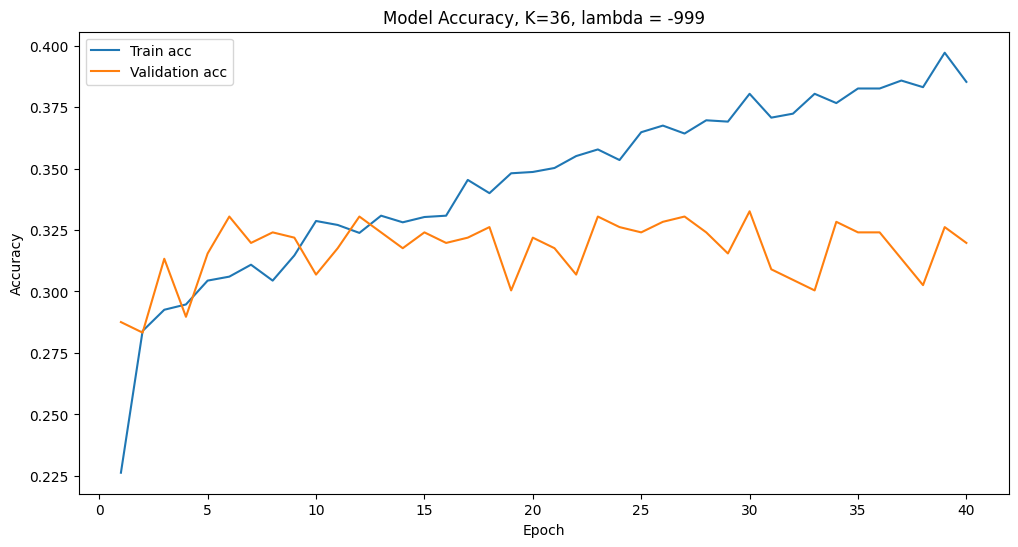

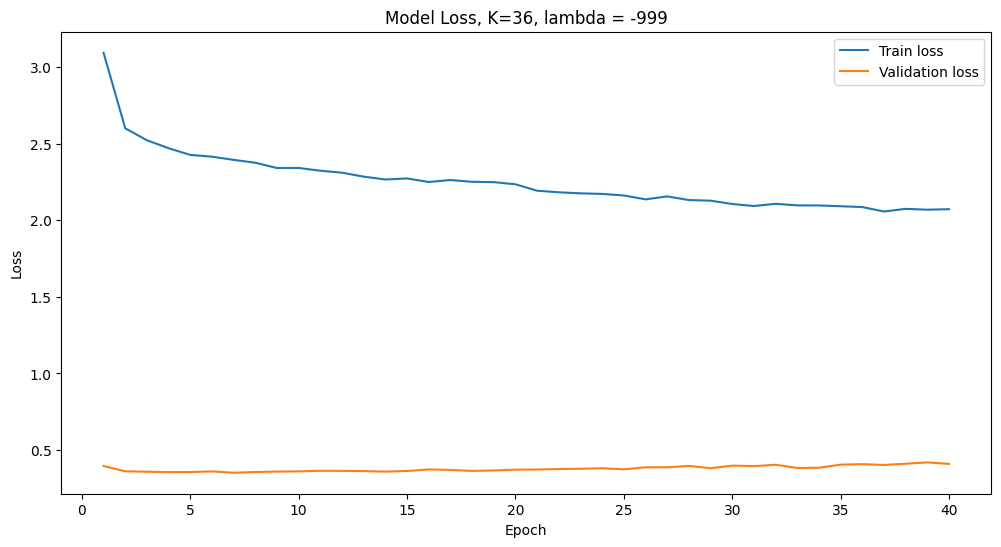

In [ ]:
# CNN
train_and_test_ConvNet(trainX, trainY_onehot, testX, testY_onehot, './', 36, -999)

In [ ]:
0